# Solar/Wind Energy Simulation with Battery System
This notebook will illustrate how the solar panels and wind turbines where simulated using the pvlib and windpowerlib libraries for the town of Moosonee, Ontario.

The following tutorials were used: 
- https://www.reimagine-energy.ai/p/code-tutorial-simulating-rooftop
- https://windpowerlib.readthedocs.io/en/stable/modelchain_example_notebook.html

In [11]:
# Import of all the necessary packages

import math
import pandas as pd
import plotly.graph_objects as go

import pvlib
from pvlib import location, pvsystem, irradiance, atmosphere, solarposition
from pvlib.pvsystem import PVSystem
from pvlib.location import Location
from plotly.subplots import make_subplots
from windpowerlib import WindTurbine, create_power_curve
from windpowerlib import ModelChain as Md
from matplotlib  import pyplot  as plt

## First loading and cleaning the weather data

In [ ]:
weather = pd.read_csv('moosenee_weather2024.csv')


In [4]:
# create new datetime column using the columns year, month, day, hour, minute
weather['datetime'] = pd.to_datetime(weather[['Year', 'Month', 'Day', 'Hour', 'Minute']])
weather_df = weather.copy()
weather_df.set_index('datetime', inplace=True)
weather_df.index = pd.to_datetime(weather_df.index)


# resample to hourly
weather_df = weather_df.resample('h').mean()

# rename columns to use the pvlib nomenclature
weather_df = weather_df.rename(
            {
                "Temperature": "temp_air",
                "Wind Speed": "wind_speed",
                "Relative Humidity": "humidity",
                "Precipitable Water": "precipitable_water",
                "GHI": "ghi",
                "DNI": "dni",
                "DHI": "dhi",
            },
            axis=1,
        )

# convert values to float
weather_df['temp_air'] = weather_df['temp_air'].astype(float)
weather_df['wind_speed'] = weather_df['wind_speed'].astype(float)
weather_df['humidity'] = weather_df['humidity'].astype(float)
weather_df['precipitable_water'] = weather_df['precipitable_water'].astype(float)
weather_df['ghi'] = weather_df['ghi'].astype(float)
weather_df['dni'] = weather_df['dni'].astype(float)
weather_df['dhi'] = weather_df['dhi'].astype(float)

# select only relevant columns
weather_df = weather_df[['temp_air', 'wind_speed', 'humidity', 'precipitable_water', 'ghi', 'dni', 'dhi', ]]

# resample to hourly
weather_df = weather_df.resample('h').mean()
weather_df.head()

,temp_air,wind_speed,humidity,precipitable_water,ghi,dni,dhi
datetime,,,,,,,
2024-01-01 00:00:00,-15.0,0.9,73.12,0.7,0.0,0.0,0.0
2024-01-01 01:00:00,-14.8,1.0,72.75,0.7,0.0,0.0,0.0
2024-01-01 02:00:00,-14.5,1.1,72.36,0.7,0.0,0.0,0.0
2024-01-01 03:00:00,-14.2,1.2,72.59,0.8,0.0,0.0,0.0
2024-01-01 04:00:00,-13.8,1.3,72.47,0.8,0.0,0.0,0.0


## Solar Panel Modelling

In [5]:
# Getting the appropriate solar panel data 

cec_modules = pvlib.pvsystem.retrieve_sam("cecmod")
module = cec_modules["LONGi_Green_Energy_Technology_Co___Ltd__LR6_72HBD_385M"]
temperature_model_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS[
    "sapm"
]["open_rack_glass_glass"]

# Create a Location and a PV System
loc = Location(
    latitude=51.25,
    longitude=-80.66,
    name="Moosenee ON",
    altitude=8,
    tz='US/Eastern',
)


surface_tilt=35,
surface_azimuth=130

In [6]:
# Solar position 
solpos = loc.get_solarposition(weather_df.index)

#POA irradiance 
poa = pvlib.irradiance.get_total_irradiance(
    surface_tilt=surface_tilt,
    surface_azimuth=surface_azimuth,
    solar_zenith=solpos["apparent_zenith"],
    solar_azimuth=solpos["azimuth"],
    dni=weather_df["dni"],
    ghi=weather_df["ghi"],
    dhi=weather_df["dhi"],
)

# ── Cell temperature using real temp_air and wind_speed ──────────
cell_temp = pvlib.temperature.sapm_cell(
    poa_global=poa["poa_global"],
    temp_air=weather_df["temp_air"],
    wind_speed=weather_df["wind_speed"],
    **temperature_model_parameters
)

# CEC single-diode DC model 
cec_params = pvlib.pvsystem.calcparams_cec(
    effective_irradiance=poa["poa_global"],
    temp_cell=cell_temp,
    alpha_sc=module["alpha_sc"],
    a_ref=module["a_ref"],
    I_L_ref=module["I_L_ref"],
    I_o_ref=module["I_o_ref"],
    R_sh_ref=module["R_sh_ref"],
    R_s=module["R_s"],
    Adjust=module["Adjust"],
)

dc = pvlib.pvsystem.singlediode(*cec_params)
dc_power = dc["p_mp"].clip(lower=0)

#Results 
print("=== DC-only results (real weather) ===")
print(f"Peak DC power   : {dc_power.max():.1f} W")
print(f"Annual DC energy: {dc_power.sum() / 1000:.1f} kWh")
print(f"Capacity factor : {dc_power.mean() / module['STC'] * 100:.1f}%")

# Attach back to weather_df for easy analysis
weather_df["poa_global"] = poa["poa_global"]
weather_df["cell_temp"]  = cell_temp
weather_df["p_mp"]       = dc_power
weather_df["v_mp"]       = dc["v_mp"]
weather_df["i_mp"]       = dc["i_mp"]

weather_df[["ghi", "poa_global", "cell_temp", "p_mp", "v_mp", "i_mp"]].head(10)

=== DC-only results (real weather) ===
Peak DC power   : 375.2 W
Annual DC energy: 412.6 kWh
Capacity factor : 12.2%


c:\Users\anast\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\optimize\_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


,ghi,poa_global,cell_temp,p_mp,v_mp,i_mp
datetime,,,,,,
2024-01-01 00:00:00,0.0,0.00000,-15.000000,-0.000000e+00,-6.544995e-17,0.000000e+00
2024-01-01 01:00:00,0.0,0.00000,-14.800000,-0.000000e+00,-2.368002e-16,0.000000e+00
2024-01-01 02:00:00,0.0,0.00000,-14.500000,-0.000000e+00,-1.713502e-16,0.000000e+00
2024-01-01 03:00:00,0.0,0.00000,-14.200000,-0.000000e+00,-1.713502e-16,0.000000e+00
2024-01-01 04:00:00,0.0,0.00000,-13.800000,1.666190e-46,-1.056073e-16,-1.577722e-30
2024-01-01 05:00:00,0.0,0.00000,-13.200000,-0.000000e+00,-6.544995e-17,0.000000e+00
2024-01-01 06:00:00,0.0,0.00000,-12.500000,0.000000e+00,0.000000e+00,3.155444e-30
2024-01-01 07:00:00,0.0,0.00000,-11.800000,0.000000e+00,0.000000e+00,3.155444e-30
2024-01-01 08:00:00,5.0,4.66091,-10.854914,1.760933e+00,3.993771e+01,4.409198e-02


## Singular Panel Results

In [7]:
# Plot
monthly_kwh = dc_power.resample('ME').sum() / 1000

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Daily DC Energy', 'Monthly DC Energy'),
    vertical_spacing=0.10,
    row_heights=[0.6, 0.4],
)
fig.add_trace(go.Scatter(
    x=dc_power.index, y=dc_power, mode='lines',
    name='DC Energy (Wh)', line=dict(color='royalblue', width=1),
), row=1, col=1)
fig.add_trace(go.Bar(
    x=monthly_kwh.index.strftime('%b'), y=monthly_kwh.round(2),
    name='Monthly Energy (kWh)', marker_color='royalblue',
    text=monthly_kwh.round(2),
    textposition='auto',
    texttemplate='%{text:.1f}',
), row=2, col=1)

# Find peak of dc_power
peak_idx = dc_power.idxmax()
peak_val = dc_power.max()

fig.add_annotation(
    x=peak_idx,
    y=peak_val,
    text=f'Peak: {peak_val:.0f} Wh',
    showarrow=True,
    arrowhead=2,
    arrowcolor='firebrick',
    ax=40,
    ay=-40,
    font=dict(color='firebrick', size=12),
    row=1, col=1,
)

fig.update_layout(
    title='DC Output — LONGi LR6-72HBD-385M | Moosonee ON',
    hovermode='x unified', template='plotly_white',
    showlegend=False, height=700,
)
fig.update_yaxes(title_text='Energy (Wh)',   row=1, col=1)
fig.update_yaxes(title_text='Energy (kWh)', row=2, col=1)
fig.update_xaxes(title_text='Month',        row=2, col=1)
fig.show()
fig.write_image("dc_output.svg")

## Solar System Modelling

In [8]:
# Panel Dimensions

panel_height = 2.02
panel_width = 0.996
panel_peak_power = 385
tilt_angle = 35
orientation = 130

# Calculate the area occupied by the PV panel on a flat roof
panel_area_flat_roof = (
        panel_height
        * panel_width
        * math.cos(tilt_angle * math.pi / 180)
    )

# calculate amount of panels that fit in a certain roof area
roof_area = 45
panel_count = math.floor(roof_area / panel_area_flat_roof)

# calculate the peak capacity of this system in kWp
system_peak_capacity = panel_count * panel_peak_power / 1000

print(f"Based on the specified system characteristics, {panel_count} panels can be installed on a {roof_area} m² flat roof. \nThis corresponds to a total system capacity of {system_peak_capacity} kWp.")

Based on the specified system characteristics, 27 panels can be installed on a 45 m² flat roof. 
This corresponds to a total system capacity of 10.395 kWp.


In [9]:
# Calculate the monthly production of the entire PV installation 
system_production = panel_count * dc_power / 1000
monthly_production = system_production.resample('ME').sum() 

# Plot monthly production
fig = go.Figure()
fig.add_trace(go.Bar(
    x=monthly_production.index.strftime('%b'),
    y=monthly_production.round(2),
    marker_color='royalblue',
    text=monthly_production.round(2),
    textposition='inside',
    texttemplate='%{text:.1f}',
))
fig.update_layout(
    title=f'Monthly System Production — {panel_count} × LONGi LR6-72HBD-385M | Moosonee ON',
    yaxis_title='Energy Produced (kWh)',
    xaxis_title='Month',
    template='plotly_white',
    yaxis=dict(range=[0, monthly_production.max() * 1.15]),
)
fig.show()
fig.write_image("dc_output_system.svg")

## Wind Turbine Modelling

In [ ]:
# data preparation for the turbine power curve
my_data = pd.read_csv("Tesup_Atlas_2.0_Turbine.csv")

my_turbine = {
    "nominal_power": 10000,  
    "hub_height": 5,  
    "power_curve": create_power_curve(
        wind_speed=my_data["Wind_Speed m/s"], power=my_data["Power W"]
    ),
}

my_turbine = WindTurbine(**my_turbine)

#wind data preparation
wind_weather = pd.read_csv("en_climate_hourly_ON_6075420_2025_full_year.csv")
wind_weather = wind_weather[['Year', 'Month', 'Day', 'Time','Temp', 'Wind Spd (km/h)', 'Stn Press (kPa)']]

wind_weather['datetime'] = pd.to_datetime(
    wind_weather['Year'].astype(str) + '-' +
    wind_weather['Month'].astype(str).str.zfill(2) + '-' +
    wind_weather['Day'].astype(str).str.zfill(2) + ' ' +
    wind_weather['Time'].astype(str).str.replace(':', '', regex=False).str.zfill(4),
    format='%Y-%m-%d %H%M'
)

wind_weather = wind_weather[['datetime', 'Temp', 'Wind Spd (km/h)', 'Stn Press (kPa)']]
wind_weather = wind_weather.rename(
    {
        'Temp': 'temperature', 
        'Wind Spd (km/h)': 'wind_speed',
        'Stn Press (kPa)':'pressure',
        'datetime':'variable_name',
    },
    axis = 1
)

wind_weather = wind_weather.set_index('variable_name') 
wind_weather['pressure'] = wind_weather['pressure']*100
wind_weather['wind_speed'] = wind_weather['wind_speed']*1000/3600
wind_weather['temperature'] = wind_weather['temperature'] + 273.15
wind_weather['roughness_length'] = 0.15

wind_weather.columns = pd.MultiIndex.from_tuples([
    ('temperature',      9.1),   # measured at 2m
    ('wind_speed',      9.1),   # measured at 10m
    ('pressure',         9.1),   # surface pressure
    ('roughness_length', 0),
], names=['variable_name', 'height'])


### Wind Turbine Power Curve

c:\Users\anast\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\windpowerlib\data.py:443: WindpowerlibUserWarning: The following columns of the weather data contain invalid values like 'nan': [('temperature', 9.1), ('wind_speed', 9.1), ('pressure', 9.1)]
  warnings.warn(msg.format(nan_columns), WindpowerlibUserWarning)


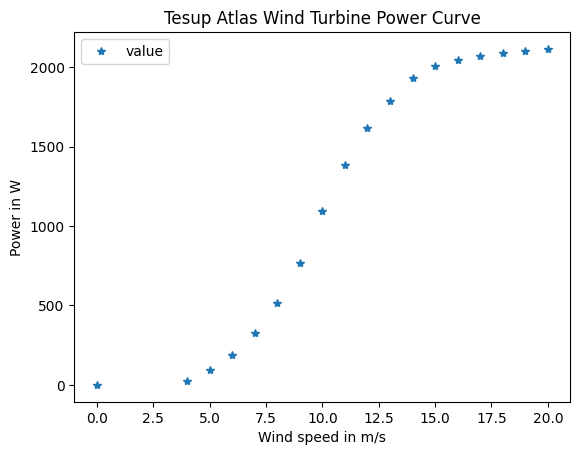

In [12]:
# running the turbine model
mc_my_turbine = Md(my_turbine).run_model(wind_weather)
my_turbine.power_output = mc_my_turbine.power_output

#plotting the power curve
if my_turbine.power_curve is not None:
    my_turbine.power_curve.plot(x='wind_speed', y='value', style='*',
                                title='Tesup Atlas Wind Turbine Power Curve')
    plt.xlabel('Wind speed in m/s')
    plt.ylabel('Power in W')
    plt.show()

## Plotting the Power Generation

In [13]:
turbine_power = my_turbine.power_output.fillna(0).clip(lower=0)
daily_wh    = turbine_power.resample('D').sum()
monthly_kwh   = turbine_power.resample('ME').sum() / 1000

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        'Daily Wind Turbine Energy',
        'Monthly Wind Turbine Energy',
    ),
    vertical_spacing=0.12,
    row_heights=[0.6, 0.4],
)

# Row 1 — hourly line
fig.add_trace(
    go.Scatter(
        x=daily_wh.index,
        y=daily_wh,
        mode='lines',
        name='Energy (Wh)',
        line=dict(color='royalblue', width=1),
    ),
    row=1, col=1,
)

# Row 2 — monthly bar
fig.add_trace(
    go.Bar(
        x=monthly_kwh.index.strftime('%b'),
        y=monthly_kwh.round(2),
        name='Energy (kWh)',
        marker_color='royalblue',
        text=monthly_kwh.round(2),
        textposition='auto',
        texttemplate='%{text:.1f}',
    ),
    row=2, col=1,
)
# Find peak of dc_power
peak_idx = daily_wh.idxmax()
peak_val = daily_wh.max()

fig.add_annotation(
    x=peak_idx,
    y=peak_val,
    text=f'Peak: {peak_val:.0f} Wh',
    showarrow=True,
    arrowhead=2,
    arrowcolor='firebrick',
    ax=40,
    ay=-40,
    font=dict(color='firebrick', size=12),
    row=1, col=1,
)

fig.update_layout(
    title='Wind Turbine Output — myTurbine',
    hovermode='x unified',
    template='plotly_white',
    showlegend=False,
    height=650,
)

fig.update_yaxes(title_text='Energy (Wh)',   row=1, col=1)
fig.update_yaxes(title_text='Energy (kWh)', row=2, col=1)
fig.update_xaxes(title_text='Month',        row=2, col=1)

fig.show()
fig.write_image("dc_output_wind.svg")